# LC SRU · Parsed Parquet 分析（书目层面）

这个笔记本做三件事：

1. 读取（或生成）`marc_parsed_analysis.parquet`（一书一行，<=30列，适合分析）。
2. 展示一条记录样例，并解释每个 column 的含义。
3. 做一些描述统计与简单图（年份、出版国家、主题词等）。

> 提醒：这里分析的是 **书目记录**（bibliographic MARC），更适合做“内容/出版结构”分析；真正的“流通/复本/馆藏地”往往在馆藏记录或流通系统里，不一定在这份数据中。

In [21]:
import json
import re
from pathlib import Path

import pandas as pd

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

# 1) DATA_ROOT 自动定位：
# - 如果你在 上机实验/01周 打开 notebook，通常可以直接用相对路径 data/lc_sru_export
# - 否则回退到你机器上的 OneDrive 绝对路径
CANDIDATES = [
    Path("data") / "lc_sru_export",
    Path(r"/Users/hzhou/Library/CloudStorage/OneDrive-s32/教学/2026-数字图书馆前沿/上机实验/01周/data/lc_sru_export"),
]

DATA_ROOT = None
for p in CANDIDATES:
    if p.exists():
        DATA_ROOT = p
        break

if DATA_ROOT is None:
    raise FileNotFoundError("找不到 data/lc_sru_export；请确认当前工作目录，或手动设置 DATA_ROOT")

DATA_ROOT

PosixPath('data/lc_sru_export')

## 解析表（<=30列）字段说明

我们把 MARC 里“适合做馆藏结构/内容分析”的字段抽成一书一行。重复字段（比如多个 `650$a`）会用 ` | ` 合并去重。

| 列名 | 含义（来源） | 典型用途 |
|---|---|---|
| `bib_id` | 记录号（MARC `001`） | 主键、链接 flat 表 |
| `country_008` | 出版国家代码（controlfield `008` 位置 15-17） | 出版国家分布、与主题/学科关联 |
| `lang_008` | 语言代码（`008` 位置 35-37） | 语种结构 |
| `langs_041$a` | 041$a（可重复） | 多语种记录补充 |
| `lccn_010$a` | 010$a（LCCN） | 去重、外部链接 |
| `isbn_020$a` | 020$a（ISBN） | 去重、外部链接 |
| `issn_022$a` | 022$a（ISSN） | 连续出版物识别 |
| `title_245$a` | 245$a 正题名 | 关键词/主题模型 |
| `title_245$b` | 245$b 其他题名信息 | 标题补全 |
| `resp_245$c` | 245$c 责任说明 | 作者/机构辅助 |
| `author_100$a` | 100$a 主要责任者 | 作者网络 |
| `contributors_700$a` | 700$a 附加个人名称 | 合作网络 |
| `lc_class_050` | 050$a+$b（LC 分类号） | 学科结构 |
| `pub_place` | 260/264$a 出版地（优先 264） | 出版地结构 |
| `publisher` | 260/264$b 出版者 | 出版者集中度 |
| `pub_date_raw` | 260/264$c 原始出版时间字符串 | 清洗/回溯 |
| `pub_year` | 从 `pub_date_raw` 抽取的四位年（粗提取） | 年份趋势 |
| `extent_300$a` | 300$a 载体/页数等 | 形态画像 |
| `content_336$a` | 336$a 内容类型 | 资源类型 |
| `media_337$a` | 337$a 媒介类型 | 资源类型 |
| `carrier_338$a` | 338$a 载体类型 | 资源类型 |
| `abstract_520$a` | 520$a 摘要（可能为空） | 内容分析强信号 |
| `toc_505$a` | 505$a 目录（可能为空） | 章节级内容 |
| `subject_650$a` | 650$a 主题词主目（可重复） | 主题结构 |
| `subject_650$x` | 650$x 一般附分 | 主题细分 |
| `subject_650$y` | 650$y 年代附分 | 时间语义 |
| `subject_650$z` | 650$z 地理附分（你关心的“650里的地理”） | 地理分析、主题-地点 |
| `geo_651$a` | 651$a 地名主题词 | 地理分析主来源 |
| `genre_655$a` | 655$a 体裁/类型 | 文献类型 |
| `url_856$u` | 856$u URL | 电子资源链接 |


In [22]:
# 2) 读取（或生成）解析后的分析表 parquet

parsed_path = DATA_ROOT / "marc_parsed_analysis.parquet"
one_row_path = DATA_ROOT / "marc_bibli_one_row.parquet"

def join_unique(values, sep=" | "):
    out, seen = [], set()
    for v in values:
        if v is None or (isinstance(v, float) and pd.isna(v)):
            continue
        s = str(v).strip()
        if not s or s in seen:
            continue
        seen.add(s)
        out.append(s)
    return sep.join(out) if out else None

def first_value(values):
    for v in values:
        if v is None or (isinstance(v, float) and pd.isna(v)):
            continue
        s = str(v).strip()
        if s:
            return s
    return None

year_re = re.compile(r"((?:1|2)\d{3})")

if parsed_path.exists():
    df_parsed = pd.read_parquet(parsed_path)
else:
    df_one = pd.read_parquet(one_row_path)
    records = []

    for _, r in df_one.iterrows():
        bib_id = str(r["bib_id"])
        fields = json.loads(r["marc_json"])  # list[dict]

        data_map = {}  # (tag, sub) -> list[str]
        ctrl_map = {}  # tag -> list[str]

        for f in fields:
            kind = f.get("kind")
            tag = f.get("tag")
            if not tag:
                continue

            if kind == "data":
                sub = f.get("subfield_code")
                if not sub:
                    continue
                data_map.setdefault((tag, sub), []).append(f.get("value"))
            elif kind == "control":
                ctrl_map.setdefault(tag, []).append(f.get("value"))

        def allv(tag, sub):
            return data_map.get((tag, sub), [])

        def first(tag, sub):
            return first_value(allv(tag, sub))

        def join(tag, sub, sep=" | "):
            return join_unique(allv(tag, sub), sep=sep)

        v008 = first_value(ctrl_map.get("008", []))
        country_008 = v008[15:18] if isinstance(v008, str) and len(v008) >= 18 else None
        lang_008 = v008[35:38] if isinstance(v008, str) and len(v008) >= 38 else None

        has_264 = any(k[0] == "264" for k in data_map.keys())
        pub_tag = "264" if has_264 else "260"
        pub_place = join(pub_tag, "a")
        publisher = join(pub_tag, "b")
        pub_date_raw = join(pub_tag, "c")

        pub_year = None
        if pub_date_raw:
            m = year_re.search(pub_date_raw)
            pub_year = int(m.group(1)) if m else None

        t050a = first("050", "a")
        t050b = first("050", "b")
        lc_class_050 = (" ".join([x for x in [t050a, t050b] if x]).strip() or None)

        records.append({
            "bib_id": bib_id,
            "country_008": country_008,
            "lang_008": lang_008,
            "langs_041$a": join("041", "a"),
            "lccn_010$a": join("010", "a"),
            "isbn_020$a": join("020", "a"),
            "issn_022$a": join("022", "a"),
            "title_245$a": first("245", "a"),
            "title_245$b": first("245", "b"),
            "resp_245$c": first("245", "c"),
            "author_100$a": first("100", "a"),
            "contributors_700$a": join("700", "a"),
            "lc_class_050": lc_class_050,
            "pub_place": pub_place,
            "publisher": publisher,
            "pub_date_raw": pub_date_raw,
            "pub_year": pub_year,
            "extent_300$a": join("300", "a"),
            "content_336$a": join("336", "a"),
            "media_337$a": join("337", "a"),
            "carrier_338$a": join("338", "a"),
            "abstract_520$a": join("520", "a", sep="\n"),
            "toc_505$a": join("505", "a", sep="\n"),
            "subject_650$a": join("650", "a"),
            "subject_650$x": join("650", "x"),
            "subject_650$y": join("650", "y"),
            "subject_650$z": join("650", "z"),
            "geo_651$a": join("651", "a"),
            "genre_655$a": join("655", "a"),
            "url_856$u": join("856", "u"),
        })

    df_parsed = pd.DataFrame(records)
    df_parsed.to_parquet(parsed_path, index=False)

parsed_path, df_parsed.shape, list(df_parsed.columns)

(PosixPath('data/lc_sru_export/marc_parsed_analysis.parquet'),
 (1141, 30),
 ['bib_id',
  'country_008',
  'lang_008',
  'langs_041$a',
  'lccn_010$a',
  'isbn_020$a',
  'issn_022$a',
  'title_245$a',
  'title_245$b',
  'resp_245$c',
  'author_100$a',
  'contributors_700$a',
  'lc_class_050',
  'pub_place',
  'publisher',
  'pub_date_raw',
  'pub_year',
  'extent_300$a',
  'content_336$a',
  'media_337$a',
  'carrier_338$a',
  'abstract_520$a',
  'toc_505$a',
  'subject_650$a',
  'subject_650$x',
  'subject_650$y',
  'subject_650$z',
  'geo_651$a',
  'genre_655$a',
  'url_856$u'])

In [23]:
# 3) 展示一条记录（挑非空字段最多的一条）

non_null = df_parsed.notna().sum(axis=1)
i = int(non_null.idxmax())
sample = df_parsed.loc[i]
print("sample index:", i, "bib_id:", sample["bib_id"], "non-null cols:", int(non_null.loc[i]))
sample

sample index: 51 bib_id: 12736827 non-null cols: 26


bib_id                                                         12736827
country_008                                                         ilu
lang_008                                                            eng
langs_041$a                                                        None
lccn_010$a                                                   2002005477
isbn_020$a                      0812626664 | 081262677X | 9780812626667
issn_022$a                                                         None
title_245$a                                        Caravan to America :
title_245$b                              living arts of the Silk Road /
resp_245$c                          John S. Major and Betty J. Belanus.
author_100$a                                             Major, John S.
contributors_700$a                                    Belanus, Betty J.
lc_class_050                                            NX575 .C37 2002
pub_place                                                     Ch

## 描述统计 1：缺失率（哪些字段最常缺）

In [24]:
missing_pct = (df_parsed.isna().mean().sort_values(ascending=False) * 100).round(1)
missing_pct.to_frame("missing_%")

,missing_%
issn_022$a,99.7
subject_650$y,94.7
url_856$u,93.1
toc_505$a,90.7
abstract_520$a,87.5
langs_041$a,82.1
genre_655$a,69.8
subject_650$x,65.6
contributors_700$a,59.7
subject_650$z,53.6


## 描述统计 2：出版年份（粗提取）

In [25]:
df_parsed["pub_year"].describe()

count    1139.000000
mean     2005.951712
std        33.471000
min      1387.000000
25%      1998.000000
50%      2010.000000
75%      2018.000000
max      2543.000000
Name: pub_year, dtype: float64

In [26]:
year_counts = df_parsed["pub_year"].dropna().astype(int).value_counts().sort_index()
year_counts.tail(25)

pub_year
2003    21
2004    26
2005    24
2006    17
2007    28
2008    37
2009    23
2010    40
2011    30
2012    22
2013    18
2014    28
2015    40
2016    66
2017    62
2018    55
2019    50
2020    36
2021    54
2022    39
2023    34
2024    15
2025     7
2026     3
2543     1
Name: count, dtype: int64

<Axes: title={'center': 'Publications by Year (from 260/264$c, rough)'}, xlabel='Year', ylabel='Count'>

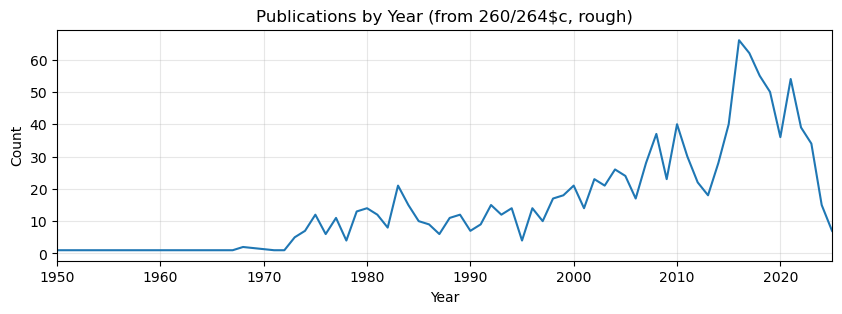

In [29]:
# 简单图：出版年趋势
ax = year_counts.plot(kind="line", figsize=(10, 3), title="Publications by Year (from 260/264$c, rough)")
ax.set_xlabel("Year")
ax.set_ylabel("Count")
ax.set_xlim(1950,2025)
ax.grid(True, alpha=0.3)
ax

## 描述统计 3：出版国家或地区（`008/15-17` 代码）

In [30]:
country_counts = df_parsed["country_008"].fillna("(missing)").value_counts().head(20)
country_counts

country_008
cc     454
ja      98
xx      75
nyu     57
enk     53
ii      34
fr      28
ko      27
gw      25
ru      21
cau     17
uz      17
tu      17
ne      17
it      16
kz      15
ch      13
be      10
dcu      9
mau      9
Name: count, dtype: int64

<Axes: title={'center': 'Top Country or Territory Codes (008/15-17)'}, xlabel='Count', ylabel='country_008'>

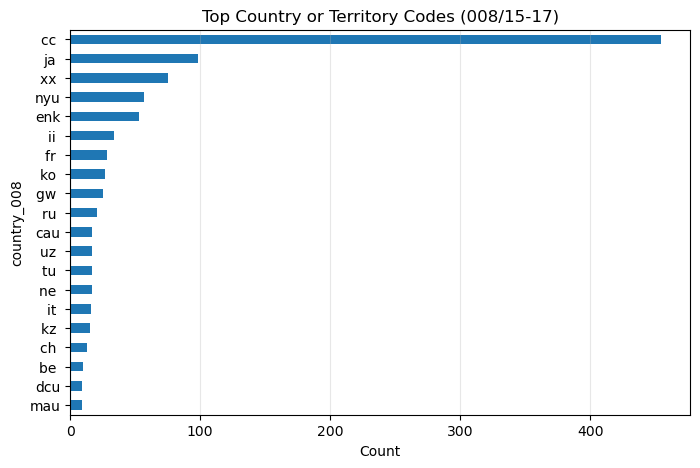

In [32]:
ax = country_counts.sort_values().plot(kind="barh", figsize=(8, 5), title="Top Country or Territory Codes (008/15-17)")
ax.set_xlabel("Count")
ax.grid(True, axis="x", alpha=0.3)
ax

### `country_008`（MARC 008/15-17 出版地代码）释义

> 这组代码来自 Library of Congress 的 *MARC Code List for Countries*。注意：它不只是“国家”，也包含美国各州/地区（所以会看到 `nyu/cau/dcu/mau` 这种）。

| code | 含义（可读名称） | 备注 |
|---|---|---|
| `cc` | China（中国） |  |
| `ja` | Japan（日本） |  |
| `xx` | No place, unknown, or undetermined（未知/不确定） |  |
| `nyu` | United States — New York（美国纽约州） | 美国州级代码 |
| `enk` | England（英格兰） |  |
| `ii` | India（印度） |  |
| `fr` | France（法国） |  |
| `ko` | Korea (South)（韩国） |  |
| `gw` | Germany（德国） |  |
| `ru` | Russia (Federation)（俄罗斯） |  |
| `cau` | United States — California（美国加利福尼亚州） | 美国州级代码 |
| `uz` | Uzbekistan（乌兹别克斯坦） |  |
| `tu` | Turkey（土耳其） |  |
| `ne` | Netherlands（荷兰） |  |
| `it` | Italy（意大利） |  |
| `kz` | Kazakhstan（哈萨克斯坦） |  |
| `ch` | China (Republic : 1949-)（中华民国方向） | 常被理解为台湾方向的出版地代码 |
| `be` | Belgium（比利时） |  |
| `dcu` | United States — District of Columbia（美国哥伦比亚特区/华盛顿特区） | 美国特区代码 |
| `mau` | United States — Massachusetts（美国马萨诸塞州） | 美国州级代码 |

**分析建议**：如果做“出版国家”统计，建议把 `nyu/cau/dcu/mau` 这类州/特区代码归并为 `United States`，避免结果被拆得过碎。


## 分析 5：主题/分类数量随年代变化（Topic & Classification Counts by Period）

这里把每条记录的“主题词数量/地名主题数量/体裁词数量”按年代汇总，对比不同年代的标引深度。

- 主题词：`650$a`（拆分 ` | ` 后计数）
- 地名主题：`651$a`
- 体裁/类型：`655$a`
- 分类是否存在：`lc_class_050` 是否为空（可看“有分类号的比例”）

> 注意：这反映的是书目记录的“标引/描述”特征，不等同于真实馆藏建设强度。

In [33]:
import numpy as np

def count_pipe_items(x):
    if x is None or (isinstance(x, float) and pd.isna(x)):
        return 0
    parts = [p.strip() for p in str(x).split("|")]
    parts = [p for p in parts if p]
    return len(parts)

df = df_parsed.copy()
df["n_650a"] = df["subject_650$a"].apply(count_pipe_items)
df["n_651a"] = df["geo_651$a"].apply(count_pipe_items)
df["n_655a"] = df["genre_655$a"].apply(count_pipe_items)
df["has_050"] = df["lc_class_050"].notna() & (df["lc_class_050"].astype(str).str.strip() != "")

# 年代分组：按 decade（如 1990, 2000）
df = df.dropna(subset=["pub_year"]).copy()
df["pub_year"] = df["pub_year"].astype(int)
df["decade"] = (df["pub_year"] // 10) * 10

decade_counts = df["decade"].value_counts().sort_index()
decade_counts

decade
1380      2
1960      5
1970     60
1980    118
1990    120
2000    234
2010    411
2020    188
2540      1
Name: count, dtype: int64

In [34]:
# 选记录数最多的 3 个年代做对比（你也可以手动改 periods）
top3_decades = decade_counts.sort_values(ascending=False).head(3).index.tolist()
top3_decades_sorted = sorted(top3_decades)
top3_decades_sorted

[2000, 2010, 2020]

In [47]:
top3_decades_sorted = [1980, 2000, 2020]

lc_main_top,(missing/unknown),Fine Arts,"Geography, Anthropology, Recreation",Language & Literature,Music,Other,"Philosophy, Psychology, Religion",Social Sciences,World History & History of Europe/Africa/Asia/Australia/NZ
decade,,,,,,,,,
1380,0,0,0,0,0,0,0,0,2
1960,0,4,0,0,0,0,0,0,1
1970,0,22,0,4,0,1,2,0,31
1980,0,11,4,9,6,6,5,4,73
1990,4,12,10,9,4,5,4,12,60
2000,1,18,17,4,3,19,11,18,143
2010,7,25,24,21,7,27,11,89,200
2020,15,7,8,9,1,9,4,37,98
2540,0,0,0,0,0,0,0,0,1


lc_main_top,(missing/unknown),Fine Arts,"Geography, Anthropology, Recreation",Language & Literature,Music,Other,"Philosophy, Psychology, Religion",Social Sciences,World History & History of Europe/Africa/Asia/Australia/NZ
decade,,,,,,,,,
1380,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0
1960,0.0,80.0,0.0,0.0,0.0,0.0,0.0,0.0,20.0
1970,0.0,36.7,0.0,6.7,0.0,1.7,3.3,0.0,51.7
1980,0.0,9.3,3.4,7.6,5.1,5.1,4.2,3.4,61.9
1990,3.3,10.0,8.3,7.5,3.3,4.2,3.3,10.0,50.0
2000,0.4,7.7,7.3,1.7,1.3,8.1,4.7,7.7,61.1
2010,1.7,6.1,5.8,5.1,1.7,6.6,2.7,21.7,48.7
2020,8.0,3.7,4.3,4.8,0.5,4.8,2.1,19.7,52.1
2540,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0


<Axes: title={'center': 'LC Main Class Share (050) - 1980s vs 2000s vs 2020s'}, xlabel='Decade', ylabel='Share (%)'>

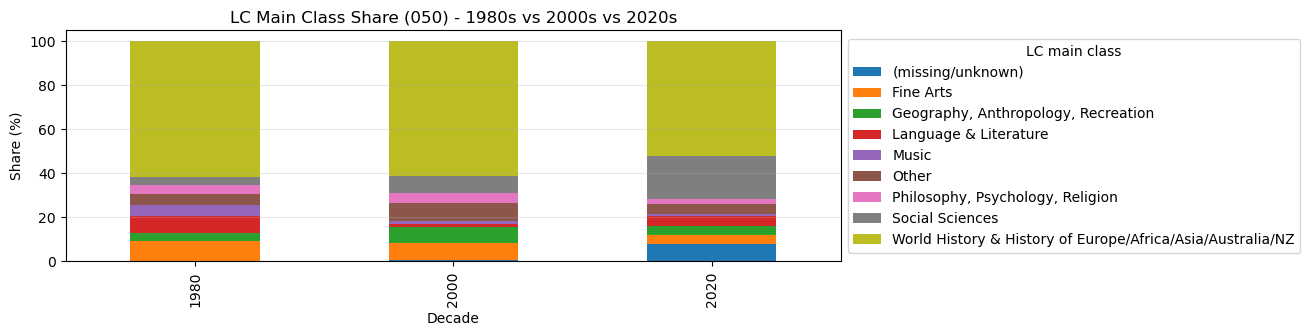

In [48]:
import re
import pandas as pd

# df_parsed 里需要有：pub_year（int/float） 和 lc_class_050（字符串，如 "NX575 .C37 2002"）
df = df_parsed.copy()

# 1) 从 LC call number 抽“分类字母”（LC Classification 的 class/subclass）
# 规则：优先取前 1-3 个大写字母（如 NX, QK, DS）
def lc_prefix(x):
    if x is None or (isinstance(x, float) and pd.isna(x)):
        return None
    m = re.match(r"^\s*([A-Z]{1,3})", str(x).strip().upper())
    return m.group(1) if m else None

df["lc_prefix"] = df["lc_class_050"].apply(lc_prefix)

# 2) 把 prefix 映射成“学科大类”（够用版，覆盖常见 A-Z 主类）
# 说明：LC 是“字母主类 + 子类”，这里先上卷到主类（第一个字母）做宏观趋势
LC_MAIN = {
    "A": "General Works",
    "B": "Philosophy, Psychology, Religion",
    "C": "Auxiliary Sciences of History",
    "D": "World History & History of Europe/Africa/Asia/Australia/NZ",
    "E": "History of the Americas (U.S.)",
    "F": "History of the Americas (Local)",
    "G": "Geography, Anthropology, Recreation",
    "H": "Social Sciences",
    "J": "Political Science",
    "K": "Law",
    "L": "Education",
    "M": "Music",
    "N": "Fine Arts",
    "P": "Language & Literature",
    "Q": "Science (incl. Biology, Physics, etc.)",
    "R": "Medicine",
    "S": "Agriculture",
    "T": "Technology",
    "U": "Military Science",
    "V": "Naval Science",
    "Z": "Bibliography, Library Science, Information Resources",
}
df["lc_main"] = df["lc_prefix"].str[0].map(LC_MAIN)
df["lc_main"] = df["lc_main"].fillna("(missing/unknown)")

# 3) 按年代（decade）统计学科分布
df = df.dropna(subset=["pub_year"]).copy()
df["pub_year"] = df["pub_year"].astype(int)
df["decade"] = (df["pub_year"] // 10) * 10

# 每个年代 Top-N 学科（其余合并为 Other，避免图太乱）
TOP_N = 8
top_cats = df["lc_main"].value_counts().head(TOP_N).index.tolist()
df["lc_main_top"] = df["lc_main"].where(df["lc_main"].isin(top_cats), "Other")

counts = pd.crosstab(df["decade"], df["lc_main_top"])
share = counts.div(counts.sum(axis=1), axis=0)

display(counts.sort_index())
display((share.sort_index() * 100).round(1))

# 4) 画图：各年代学科占比（堆叠柱状图）
# 只画 top3_decades_sorted 这三个 decade（假设你上面已经算出了 share 和 top3_decades_sorted）

decades3 = sorted(top3_decades_sorted)

plot_share = share.loc[share.index.isin(decades3)].copy().sort_index()

ax = (plot_share * 100).plot(
    kind="bar",
    stacked=True,
    figsize=(10, 3),
    title=f"LC Main Class Share (050) - {decades3[0]}s vs {decades3[1]}s vs {decades3[2]}s",
)
ax.set_xlabel("Decade")
ax.set_ylabel("Share (%)")
ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5), title="LC main class")
ax.grid(True, axis="y", alpha=0.3)
ax



In [51]:

plot_pct_str = (plot_share.T * 100).round(1).astype(str) + "%"
display(plot_pct_str)



decade,1980,2000,2020
lc_main_top,,,
(missing/unknown),0.0%,0.4%,8.0%
Fine Arts,9.3%,7.7%,3.7%
"Geography, Anthropology, Recreation",3.4%,7.3%,4.3%
Language & Literature,7.6%,1.7%,4.8%
Music,5.1%,1.3%,0.5%
Other,5.1%,8.1%,4.8%
"Philosophy, Psychology, Religion",4.2%,4.7%,2.1%
Social Sciences,3.4%,7.7%,19.7%
World History & History of Europe/Africa/Asia/Australia/NZ,61.9%,61.1%,52.1%


In [ ]:
# plot_share: index=decade, columns=lc_main_top（含 "(missing/unknown)" 这一列时）
# 目标：在每个 decade 内先去掉 missing，再重新归一化到 100%

missing_col = "(missing/unknown)"  # 如果你前面用的名字不同，这里改一下

plot_share_no_missing = plot_share.drop(columns=[missing_col], errors="ignore")
plot_share_no_missing = plot_share_no_missing.div(plot_share_no_missing.sum(axis=1), axis=0)

# 展示为干净百分比（
display((plot_share_no_missing.T * 100).style.format("{:.1f}%"))


decade,1980,2000,2020
lc_main_top,,,
Fine Arts,9.3%,7.7%,4.0%
"Geography, Anthropology, Recreation",3.4%,7.3%,4.6%
Language & Literature,7.6%,1.7%,5.2%
Music,5.1%,1.3%,0.6%
Other,5.1%,8.2%,5.2%
"Philosophy, Psychology, Religion",4.2%,4.7%,2.3%
Social Sciences,3.4%,7.7%,21.4%
World History & History of Europe/Africa/Asia/Australia/NZ,61.9%,61.4%,56.6%


## 分析 6：不同年代的 Title/Abstract 词云对比（3 个年代）

这里选 **记录数最多的 3 个年代**，分别用 `title_245$a + abstract_520$a` 合并文本生成词云（若环境没有安装 `wordcloud`，会自动退化成 Top words 柱状图）。

- 默认按英文做简单分词（小写、去标点、去停用词）
- 你也可以把 `texts = ...` 改成只用标题或只用摘要
- 如果你更希望对比固定的三个年代（例如 1980/2000/2020），直接改 `periods` 即可

In [53]:
import matplotlib.pyplot as plt
from collections import Counter

try:
    from wordcloud import WordCloud
    HAS_WORDCLOUD = True
except Exception:
    HAS_WORDCLOUD = False

STOPWORDS = {
    "the","and","of","to","in","a","an","for","on","with","by","from","at","as","is","are","was","were",
    "this","that","these","those","it","its","their","his","her","into","about","over","under","between",
    "book","books","volume","vol","edition","ed","new","one","two","three",
}

token_re = re.compile(r"[a-z]{2,}")

def tokens(text):
    if text is None or (isinstance(text, float) and pd.isna(text)):
        return []
    s = str(text).lower()
    ws = token_re.findall(s)
    return [w for w in ws if w not in STOPWORDS]

periods = top3_decades_sorted  # 默认：记录数最多的 3 个 decade
periods

[1980, 2000, 2020]

In [54]:
def build_freq_for_decade(decade: int) -> Counter:
    g = df[df["decade"] == decade]
    texts = (
        g["title_245$a"].fillna("")
        + "\n"
        + g["abstract_520$a"].fillna("")
    )
    c = Counter()
    for t in texts.tolist():
        c.update(tokens(t))
    return c

freqs = {d: build_freq_for_decade(d) for d in periods}
{d: sum(freqs[d].values()) for d in freqs}

{1980: 577, 2000: 1495, 2020: 6776}

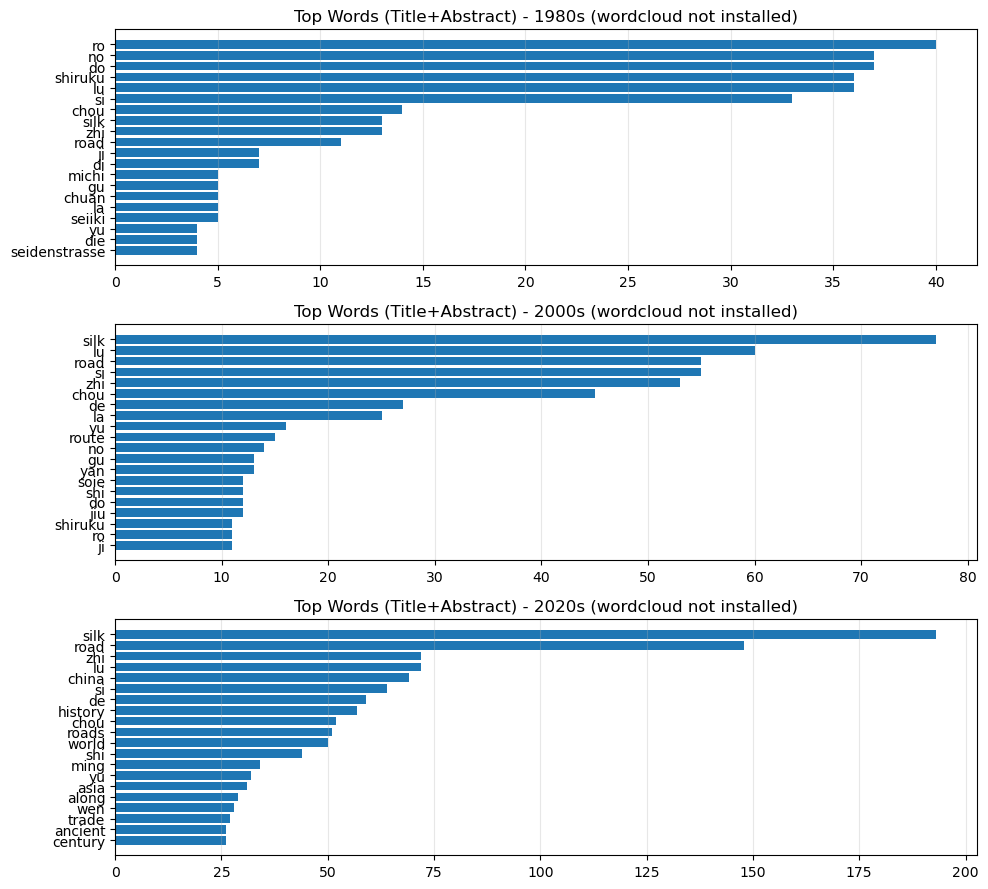

In [55]:
if HAS_WORDCLOUD:
    fig, axes = plt.subplots(1, len(periods), figsize=(5 * len(periods), 4))
    if len(periods) == 1:
        axes = [axes]
    for ax, decade in zip(axes, periods):
        wc = WordCloud(width=900, height=600, background_color="white").generate_from_frequencies(freqs[decade])
        ax.imshow(wc, interpolation="bilinear")
        ax.set_title(f"{decade}s")
        ax.axis("off")
    plt.tight_layout()
else:
    # 退化方案：每个年代画 Top 20 词频柱状图
    fig, axes = plt.subplots(len(periods), 1, figsize=(10, 3 * len(periods)))
    if len(periods) == 1:
        axes = [axes]
    for ax, decade in zip(axes, periods):
        top = freqs[decade].most_common(20)
        words = [w for w, _ in top][::-1]
        counts = [c for _, c in top][::-1]
        ax.barh(words, counts)
        ax.set_title(f"Top Words (Title+Abstract) - {decade}s (wordcloud not installed)")
        ax.grid(True, axis="x", alpha=0.3)
    plt.tight_layout()

plt.show()

## 描述统计 4：主题与地理（650/651）

这里做两件事：

1. `650$a`、`651$a` 的高频项（基于 ` | ` 拆分）。
2. `650$z`（地理附分）的高频项，作为“650里的地理信息”。

In [56]:
def split_pipe_series(s: pd.Series):
    s = s.dropna().astype(str)
    parts = s.str.split(r"\s*\|\s*")
    return parts.explode().str.strip().replace("", pd.NA).dropna()

top_650a = split_pipe_series(df_parsed["subject_650$a"]).value_counts().head(20)
top_651a = split_pipe_series(df_parsed["geo_651$a"]).value_counts().head(20)
top_650z = split_pipe_series(df_parsed["subject_650$z"]).value_counts().head(20)

top_650a, top_651a, top_650z

(subject_650$a
 Trade routes                         176
 Silk Road                             59
 Merchant marine                       42
 East and West.                        30
 Buddhism                              25
 Historic sites                        19
 International economic relations.     18
 Music                                 17
 Civilization.                         17
 Art                                   17
 Silk industry                         16
 Silk Road.                            16
 Excavations (Archaeology)             16
 Trade routes.                         16
 Silk                                  14
 Art, Chinese                          12
 Travel.                               12
 Economic history.                     12
 Civilization, Western                 11
 Antiquities.                          11
 Name: count, dtype: int64,
 geo_651$a
 Silk Road                         777
 China                             242
 Silk Road.                 

<Axes: title={'center': 'Top 650$z (Geographic subdivision)'}, xlabel='Count', ylabel='subject_650$z'>

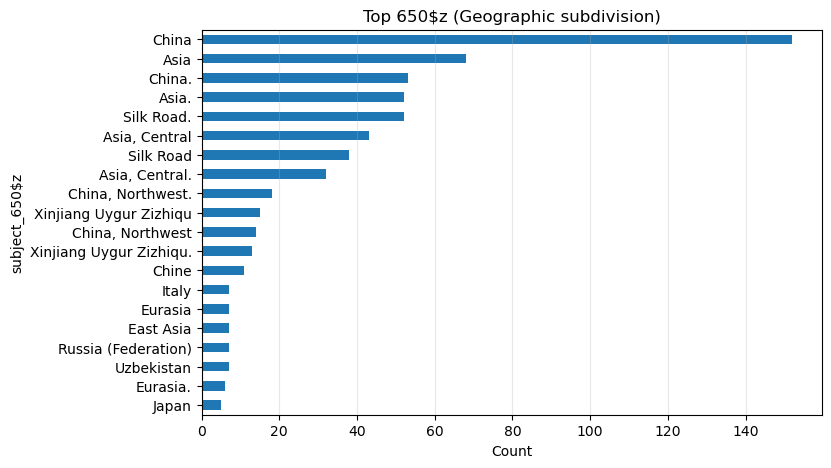

In [57]:
# 简单图：650$z 高频地理附分
ax = top_650z.sort_values().plot(kind="barh", figsize=(8, 5), title="Top 650$z (Geographic subdivision)")
ax.set_xlabel("Count")
ax.grid(True, axis="x", alpha=0.3)
ax